# Notebook — Teste do módulo `anomalies.py`

Este notebook testa o módulo:

```python
geodesy/anomalies.py
```

Serão testadas as funções:

- `gravity_disturbance`
- `free_air_correction`
- `free_air_anomaly`
- `simple_bouguer_correction`
- `bouguer_anomaly`
- `height_anomaly_from_disturbing_potential`
- `geoid_height_from_disturbing_potential`
- `deflection_of_vertical_components`

Os testes usam dados sintéticos de latitude, topografia, gravidade observada, distúrbio, anomalia de ar livre e anomalia de Bouguer.


In [1]:
# ============================================================
# 0. CONFIGURAÇÃO INICIAL
# ============================================================

import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

current_dir = Path.cwd()

if (current_dir / "geodesy").exists():
    sys.path.insert(0, str(current_dir))
    print("Pasta geodesy encontrada no diretório atual.")
else:
    print("Atenção: a pasta geodesy não foi encontrada no diretório atual.")
    print("Coloque este notebook no mesmo diretório da pasta geodesy/.")

import geodesy
from geodesy import anomalies
from geodesy import normal_gravity
from geodesy import constants

print("Versão do pacote geodesy:", geodesy.__version__)


Pasta geodesy encontrada no diretório atual.
Versão do pacote geodesy: 0.1.0


## 1. Dados sintéticos para teste


In [2]:
# ============================================================
# 1. DADOS SINTÉTICOS
# ============================================================

n = 200
x = np.linspace(0, 100, n)

lat = -3.2 + 0.5*np.sin(2*np.pi*x/100)
height = 100 + 300*np.exp(-0.5*((x-50)/12)**2) + 30*np.sin(2*np.pi*x/30)

gamma_si = normal_gravity.normal_gravity_somigliana(lat)
gamma_mgal = gamma_si * constants.SI_TO_MGAL

# Simula anomalia local em mGal
local_anomaly = 40*np.exp(-0.5*((x-55)/8)**2) - 15*np.exp(-0.5*((x-25)/5)**2)

# Gravidade observada em mGal:
# gamma - correção ar livre + anomalia local
g_obs_mgal = gamma_mgal - anomalies.free_air_correction(height) + local_anomaly

print("Lat min/max:", lat.min(), lat.max())
print("Height min/max:", height.min(), height.max())
print("g_obs min/max:", g_obs_mgal.min(), g_obs_mgal.max())


Lat min/max: -3.6999844234470785 -2.700015576552922
Height min/max: 76.76283855100316 378.6053268503954
g_obs min/max: 977946.4930628777 978029.6400208137


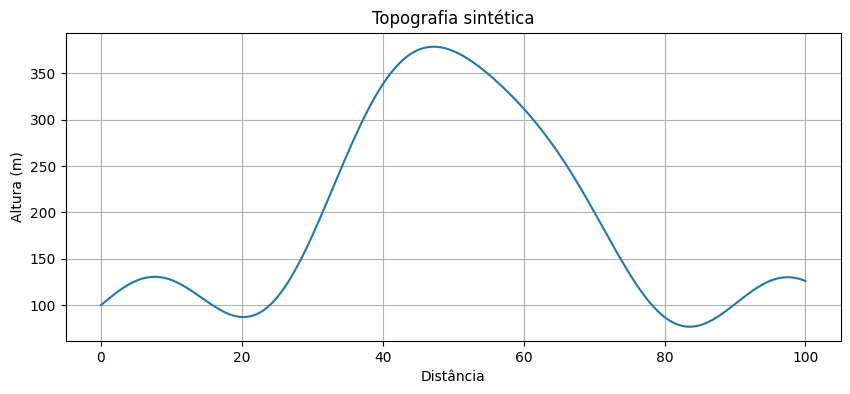

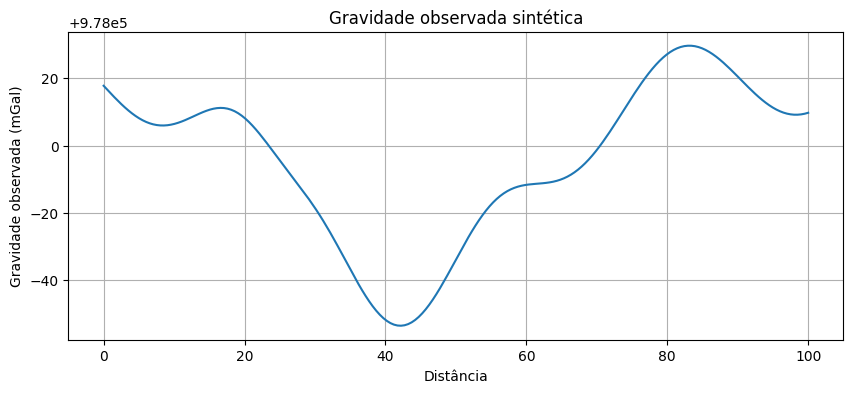

In [3]:
plt.figure(figsize=(10, 4))
plt.plot(x, height)
plt.xlabel("Distância")
plt.ylabel("Altura (m)")
plt.title("Topografia sintética")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(x, g_obs_mgal)
plt.xlabel("Distância")
plt.ylabel("Gravidade observada (mGal)")
plt.title("Gravidade observada sintética")
plt.grid(True)
plt.show()


## 2. Distúrbio da gravidade


Distúrbio min/max: -14.957773191621527 39.9840231819544


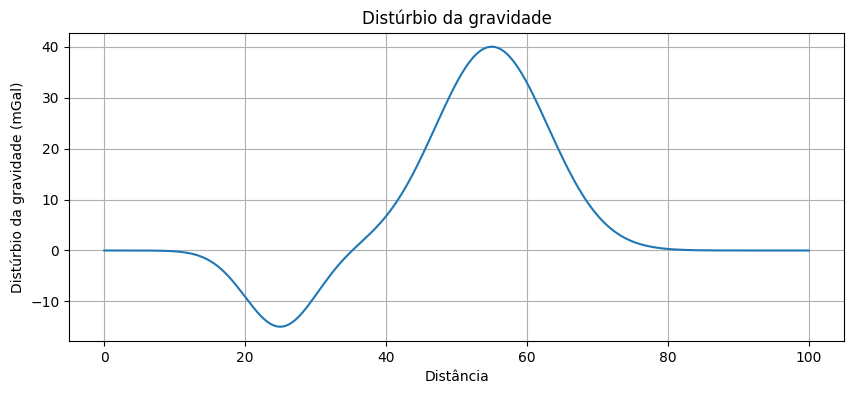

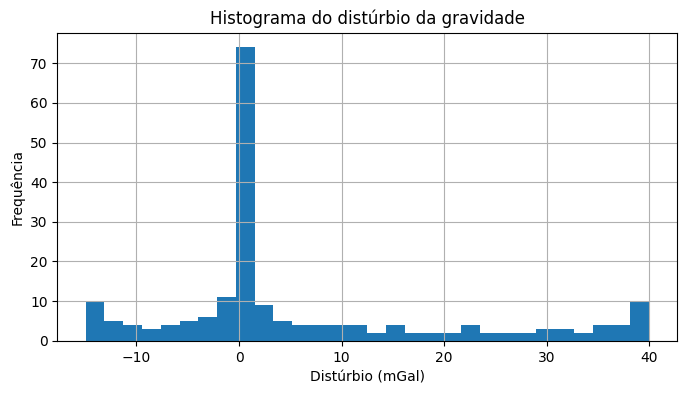

In [4]:
# ============================================================
# 2. DISTÚRBIO DA GRAVIDADE
# ============================================================

# gamma no ponto com altura
gamma_h_si = normal_gravity.normal_gravity_height(lat, height)
gamma_h_mgal = gamma_h_si * constants.SI_TO_MGAL

disturbance = anomalies.gravity_disturbance(
    g_obs_mgal,
    gamma_h_mgal,
    input_si=False,
    output_mgal=True
)

print("Distúrbio min/max:", disturbance.min(), disturbance.max())

plt.figure(figsize=(10, 4))
plt.plot(x, disturbance)
plt.xlabel("Distância")
plt.ylabel("Distúrbio da gravidade (mGal)")
plt.title("Distúrbio da gravidade")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(disturbance, bins=30)
plt.xlabel("Distúrbio (mGal)")
plt.ylabel("Frequência")
plt.title("Histograma do distúrbio da gravidade")
plt.grid(True)
plt.show()


## 3. Correção de ar livre


Correção de ar livre min/max: 23.689011976839577 116.83760386603203 mGal


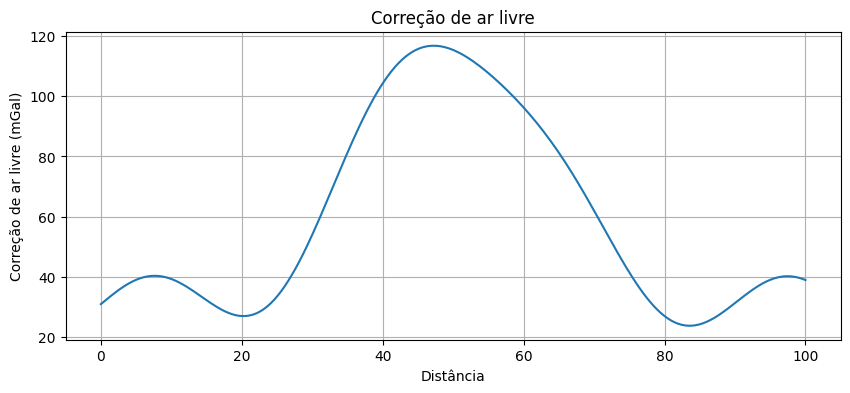

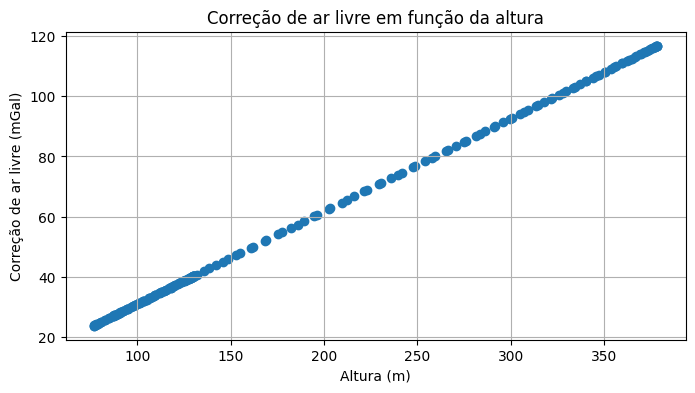

In [5]:
# ============================================================
# 3. CORREÇÃO DE AR LIVRE
# ============================================================

fac = anomalies.free_air_correction(height)

print("Correção de ar livre min/max:", fac.min(), fac.max(), "mGal")

plt.figure(figsize=(10, 4))
plt.plot(x, fac)
plt.xlabel("Distância")
plt.ylabel("Correção de ar livre (mGal)")
plt.title("Correção de ar livre")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.scatter(height, fac)
plt.xlabel("Altura (m)")
plt.ylabel("Correção de ar livre (mGal)")
plt.title("Correção de ar livre em função da altura")
plt.grid(True)
plt.show()


## 4. Anomalia de ar livre


Anomalia de ar livre min/max: -14.957773191621527 39.9840231819544


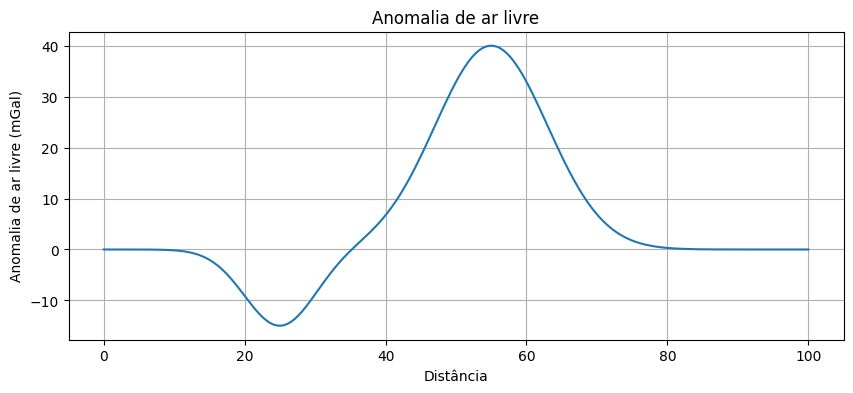

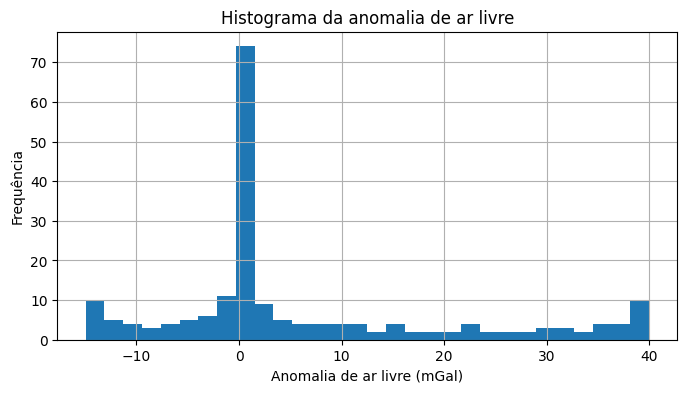

In [6]:
# ============================================================
# 4. ANOMALIA DE AR LIVRE
# ============================================================

FA = anomalies.free_air_anomaly(g_obs_mgal, lat, height)

print("Anomalia de ar livre min/max:", FA.min(), FA.max())

plt.figure(figsize=(10, 4))
plt.plot(x, FA)
plt.xlabel("Distância")
plt.ylabel("Anomalia de ar livre (mGal)")
plt.title("Anomalia de ar livre")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(FA, bins=30)
plt.xlabel("Anomalia de ar livre (mGal)")
plt.ylabel("Frequência")
plt.title("Histograma da anomalia de ar livre")
plt.grid(True)
plt.show()


## 5. Correção de Bouguer simples


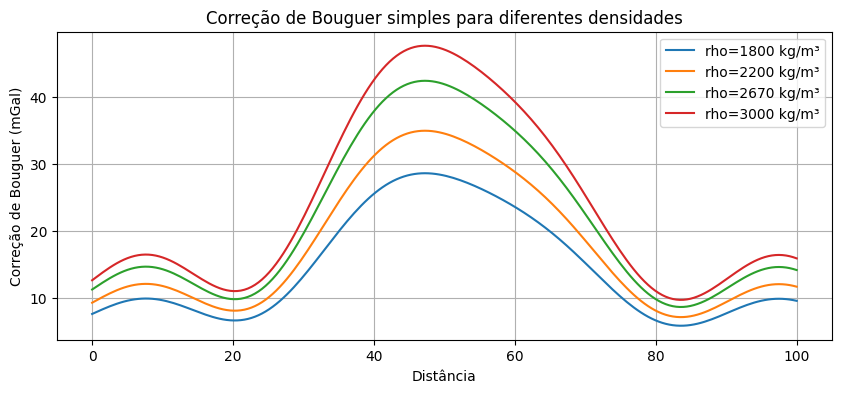

Correção para rho=2670 kg/m³ min/max:
8.595039544769401 42.39196748798403


In [7]:
# ============================================================
# 5. CORREÇÃO DE BOUGUER SIMPLES
# ============================================================

densidades = [1800, 2200, 2670, 3000]
correcoes = []

for rho in densidades:
    correcoes.append(anomalies.simple_bouguer_correction(height, density=rho))

plt.figure(figsize=(10, 4))
for rho, corr in zip(densidades, correcoes):
    plt.plot(x, corr, label=f"rho={rho} kg/m³")
plt.xlabel("Distância")
plt.ylabel("Correção de Bouguer (mGal)")
plt.title("Correção de Bouguer simples para diferentes densidades")
plt.legend()
plt.grid(True)
plt.show()

print("Correção para rho=2670 kg/m³ min/max:")
print(correcoes[2].min(), correcoes[2].max())


## 6. Anomalia de Bouguer


Bouguer 2670 min/max: -31.343646434157655 1.3627972546478873
Bouguer 2200 min/max: -25.768775743171204 8.07801207351697


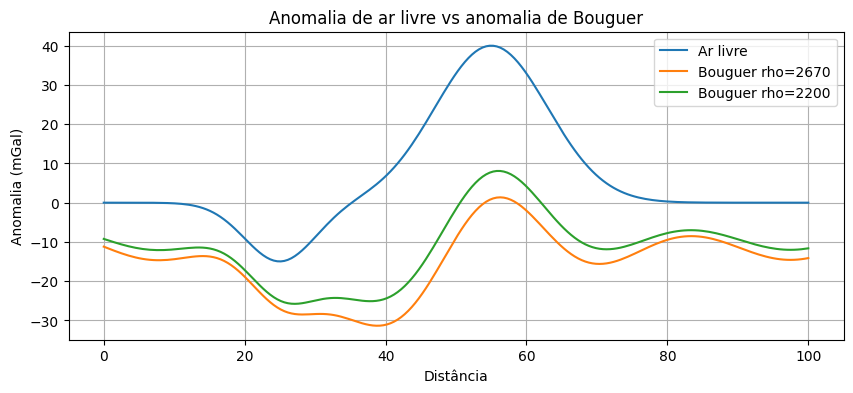

In [8]:
# ============================================================
# 6. ANOMALIA DE BOUGUER
# ============================================================

BA_2670 = anomalies.bouguer_anomaly(g_obs_mgal, lat, height, density=2670.0)
BA_2200 = anomalies.bouguer_anomaly(g_obs_mgal, lat, height, density=2200.0)

print("Bouguer 2670 min/max:", BA_2670.min(), BA_2670.max())
print("Bouguer 2200 min/max:", BA_2200.min(), BA_2200.max())

plt.figure(figsize=(10, 4))
plt.plot(x, FA, label="Ar livre")
plt.plot(x, BA_2670, label="Bouguer rho=2670")
plt.plot(x, BA_2200, label="Bouguer rho=2200")
plt.xlabel("Distância")
plt.ylabel("Anomalia (mGal)")
plt.title("Anomalia de ar livre vs anomalia de Bouguer")
plt.legend()
plt.grid(True)
plt.show()


## 7. Anomalia de altura e ondulação geoidal a partir de potencial perturbador


zeta min/max: 7.356407786432706 13.316820407153635
N min/max: 7.356407786432706 13.316820407153635


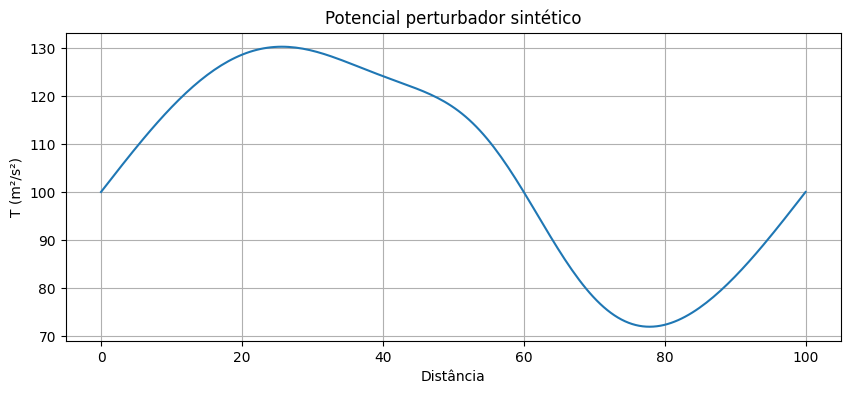

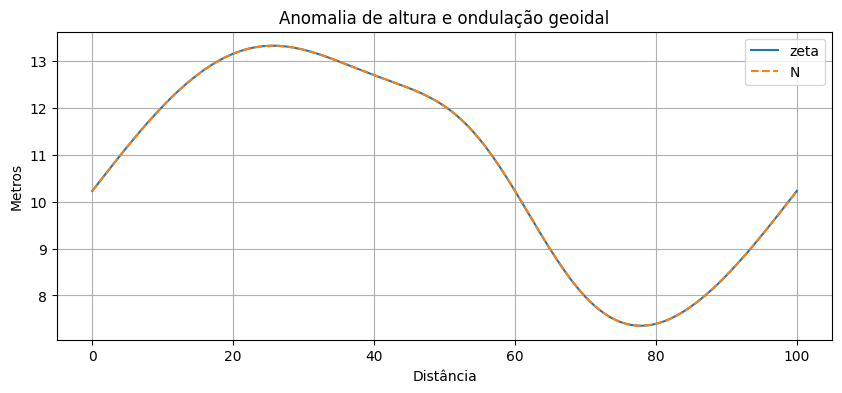

In [9]:
# ============================================================
# 7. T -> ZETA E N
# ============================================================

# Potencial perturbador sintético em m²/s²
T = 100 + 30*np.sin(2*np.pi*x/100) + 20*np.exp(-0.5*((x-55)/10)**2)

zeta = anomalies.height_anomaly_from_disturbing_potential(T, gamma_si)
N = anomalies.geoid_height_from_disturbing_potential(T, gamma_si)

print("zeta min/max:", zeta.min(), zeta.max())
print("N min/max:", N.min(), N.max())

plt.figure(figsize=(10, 4))
plt.plot(x, T)
plt.xlabel("Distância")
plt.ylabel("T (m²/s²)")
plt.title("Potencial perturbador sintético")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(x, zeta, label="zeta")
plt.plot(x, N, linestyle="--", label="N")
plt.xlabel("Distância")
plt.ylabel("Metros")
plt.title("Anomalia de altura e ondulação geoidal")
plt.legend()
plt.grid(True)
plt.show()


## 8. Deflexão da vertical


xi arcsec min/max: -39.74609204808927 52.05088991235638
eta arcsec min/max: -15.29032656762574 26.00104075073456


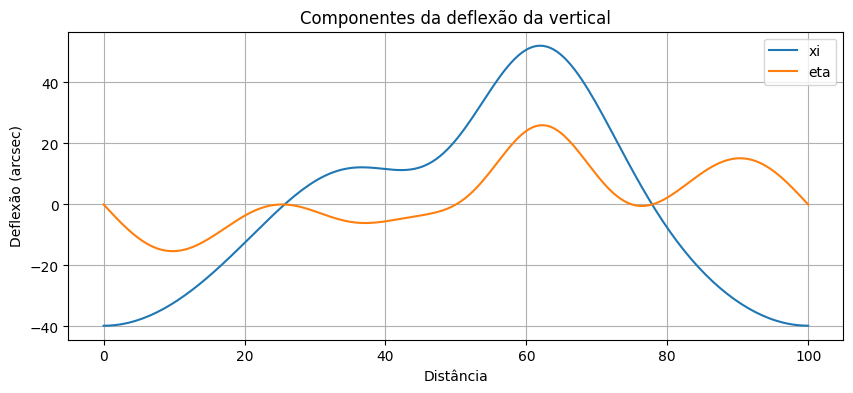

In [10]:
# ============================================================
# 8. DEFLEXÃO DA VERTICAL
# ============================================================

# Gradientes sintéticos do potencial perturbador
dT_dnorth = np.gradient(T, x * 1000)  # supondo x em km, converte para m
dT_deast = 0.5 * dT_dnorth * np.sin(2*np.pi*x/50)

xi, eta = anomalies.deflection_of_vertical_components(dT_dnorth, dT_deast, gamma_si)

# Converte para segundos de arco
rad_to_arcsec = 180/np.pi * 3600
xi_arcsec = xi * rad_to_arcsec
eta_arcsec = eta * rad_to_arcsec

print("xi arcsec min/max:", xi_arcsec.min(), xi_arcsec.max())
print("eta arcsec min/max:", eta_arcsec.min(), eta_arcsec.max())

plt.figure(figsize=(10, 4))
plt.plot(x, xi_arcsec, label="xi")
plt.plot(x, eta_arcsec, label="eta")
plt.xlabel("Distância")
plt.ylabel("Deflexão (arcsec)")
plt.title("Componentes da deflexão da vertical")
plt.legend()
plt.grid(True)
plt.show()


## 9. Mapa sintético de anomalias


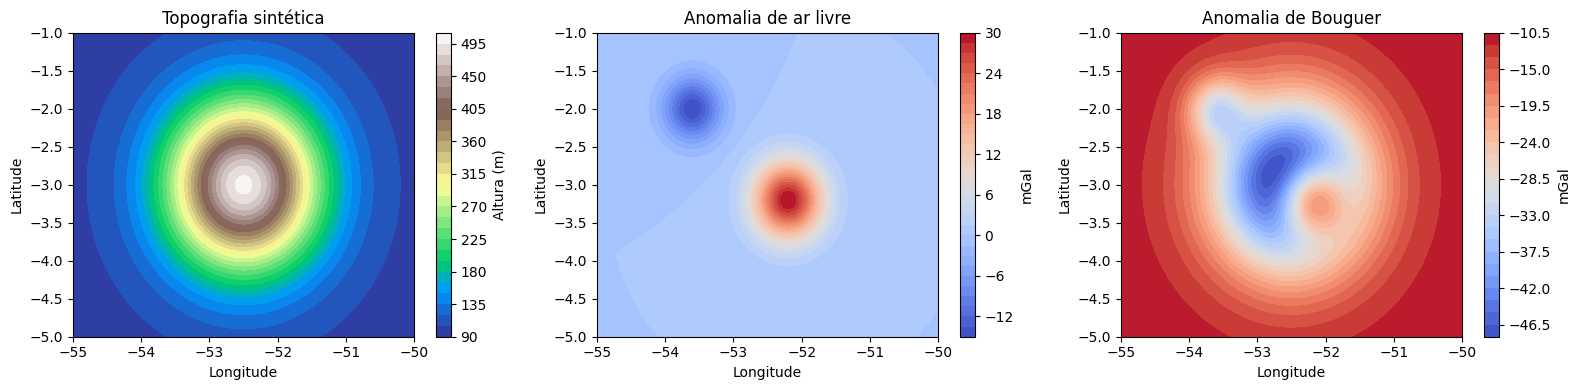

In [33]:
# ============================================================
# 9. MAPA SINTÉTICO DE ANOMALIAS
# ============================================================

lon = np.linspace(-55, -50, 120)
lat2 = np.linspace(-5, -1, 100)
LON, LAT = np.meshgrid(lon, lat2)

H = 100 + 400*np.exp(-((LON+52.5)**2 + (LAT+3.0)**2)/1.2)
GAMMA = normal_gravity.normal_gravity_somigliana(LAT) * constants.SI_TO_MGAL

ANOM_LOCAL = 30*np.exp(-((LON+52.2)**2 + (LAT+3.2)**2)/0.25) - 15*np.exp(-((LON+53.6)**2 + (LAT+2.0)**2)/0.18)
GOBS = GAMMA - anomalies.free_air_correction(H) + ANOM_LOCAL

FA_GRID = anomalies.free_air_anomaly(GOBS, LAT, H)
BA_GRID = anomalies.bouguer_anomaly(GOBS, LAT, H, density=2670.0)

plt.figure(figsize=(16, 4))

plt.subplot(1, 3, 1)
c1 = plt.contourf(LON, LAT, H, cmap="terrain", levels=30)
plt.colorbar(c1, label="Altura (m)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Topografia sintética")

plt.subplot(1, 3, 2)
c2 = plt.contourf(LON, LAT, FA_GRID, cmap="coolwarm", levels=30)
plt.colorbar(c2, label="mGal")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Anomalia de ar livre")

plt.subplot(1, 3, 3)
c3 = plt.contourf(LON, LAT, BA_GRID, cmap="coolwarm", levels=30)
plt.colorbar(c3, label="mGal")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Anomalia de Bouguer")

plt.tight_layout()
plt.show()


## 10. Resumo final


Se todas as células foram executadas sem erro, o módulo `anomalies.py` está funcionando corretamente.

O próximo notebook testa:

```python
geodesy/geoid.py
```
